In [20]:
import pandas as pd
import pyarrow.dataset as ds
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
from mplsoccer import VerticalPitch
from pathlib import Path
import os

In [21]:
dataset_shots = ds.dataset("../data/refined/fact_shots", format="parquet")
df_shots = dataset_shots.to_table().to_pandas()

dataset_players = ds.dataset("../data/refined/dim_player", format="parquet")
df_player = dataset_players.to_table().to_pandas()

dataset_match = ds.dataset("../data/refined/dim_match", format="parquet")
df_match = dataset_match.to_table().to_pandas()

dataset_player_match = ds.dataset("../data/refined/fact_player_match", format="parquet")
df_player_match = dataset_player_match.to_table().to_pandas()

In [22]:
penalties = df_shots[df_shots["result"] == "penalty"]

print("Marca do pênalti (esperado: coord_x ~11-12, coord_y = 50):")
print(penalties[["coord_x", "coord_y"]].describe().loc[["mean", "std", "min", "max"]])

Marca do pênalti (esperado: coord_x ~11-12, coord_y = 50):
        coord_x  coord_y
mean  11.464286     50.0
std    0.231455      0.0
min   10.000000     50.0
max   11.500000     50.0


In [ ]:
BACKGROUND_COLOR = "#0C0D0E"
ACCENT_COLOR = "#E4053A"

def get_font():
    try:
        return font_manager.FontProperties(family="DejaVu Sans", weight="bold")
    except Exception:
        return None

FONT = get_font()


def get_player_shots(player_name: str, include_own_goals: bool = False):
    match = df_player[df_player["player_name"].str.lower() == player_name.strip().lower()]

    if match.empty:
        print(f"Player '{player_name}' not found")
        return None, None

    player_row = match.iloc[0]
    shots = df_shots[df_shots["player_id"] == player_row["player_id"]].copy()

    if not include_own_goals:
        shots = shots[shots["result"] != "own"]

    if shots.empty:
        print(f"{player_row}['player_name']")
        return player_row, None

    shots["xg"] = shots["xg"].fillna(0.0)
    shots["pitch_x"] = 100 - shots["coord_x"]
    shots["pitch_y"] = shots["coord_y"]
    shots["is_goal"] = shots["shot_type"] == "goal"

    return player_row, shots


def calculate_stats(shots: pd.DataFrame) -> dict:
    total_shots = len(shots)
    total_goals = int(shots["is_goal"].sum())
    total_xg = shots["xg"].sum()
    xg_per_shot = total_xg / total_shots if total_shots else 0.0
    avg_distance_meters = shots["coord_x"].mean() * 0.9144

    return {
        "total_shots": total_shots,
        "total_goals": total_goals,
        "total_xg": total_xg,
        "xg_per_shot": xg_per_shot,
        "avg_distance_meters": avg_distance_meters,
    }

In [33]:
def plot_shot_map(player_row, shots: pd.DataFrame, stats: dict,
                   subtitle: str = "Shots World Cup 2026",
                   save_path: str | None = None):

    pitch = VerticalPitch(
        pitch_type="opta", half=True, pitch_color=BACKGROUND_COLOR,
        pad_bottom=.5, line_color="white", linewidth=.75, axis=True, label=True,
    )

    fig = plt.figure(figsize=(8, 12))
    fig.patch.set_facecolor(BACKGROUND_COLOR)

    ax1 = fig.add_axes([0, 0.7, 1, .2])
    ax1.set_facecolor(BACKGROUND_COLOR)
    ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)

    ax1.text(0.5, .85, player_row["player_name"], fontsize=20,
              fontproperties=FONT, fontweight="bold", color="white", ha="center")
    ax1.text(0.5, .7, subtitle, fontsize=13, fontweight="bold",
              fontproperties=FONT, color="white", ha="center")

    ax1.text(0.25, 0.5, "Low Quality Chance", fontsize=11,
              fontproperties=FONT, color="white", ha="center")
    for i, x in enumerate([0.37, 0.42, 0.48, 0.54, 0.60]):
        ax1.scatter(x=x, y=0.53, s=100 * (i + 1), color=BACKGROUND_COLOR,
                    edgecolor="white", linewidth=.8)
    ax1.text(0.75, 0.5, "High Quality Chance", fontsize=11,
              fontproperties=FONT, color="white", ha="center")

    ax1.text(0.45, 0.27, "Goal", fontsize=10, fontproperties=FONT, color="white", ha="right")
    ax1.scatter(x=0.47, y=0.3, s=100, color=ACCENT_COLOR, edgecolor="white", linewidth=.8, alpha=.85)
    ax1.scatter(x=0.53, y=0.3, s=100, color=BACKGROUND_COLOR, edgecolor="white", linewidth=.8)
    ax1.text(0.55, 0.27, "No Goal", fontsize=10, fontproperties=FONT, color="white", ha="left")
    ax1.set_axis_off()

    ax2 = fig.add_axes([.05, 0.25, .9, .5])
    ax2.set_facecolor(BACKGROUND_COLOR)
    pitch.draw(ax=ax2)

    avg_dist_pitch_x = 100 - (stats["avg_distance_meters"] / 1.2)
    ax2.scatter(x=90, y=avg_dist_pitch_x, s=100, color="white", linewidth=.8)
    ax2.plot([90, 90], [100, avg_dist_pitch_x], color="white", linewidth=2)
    ax2.text(90, avg_dist_pitch_x - 4,
              f"Average Distance\n{stats['avg_distance_meters']:.1f} meters",
              fontsize=10, fontproperties=FONT, color="white", ha="center")

    for shot in shots.to_dict(orient="records"):
        pitch.scatter(
            shot["pitch_x"], shot["pitch_y"],
            s=max(300 * shot["xg"], 20),
            color=ACCENT_COLOR if shot["is_goal"] else BACKGROUND_COLOR,
            ax=ax2, alpha=.75, linewidth=.8, edgecolor="white",
        )
    ax2.set_axis_off()

    ax3 = fig.add_axes([0, .2, 1, .05])
    ax3.set_facecolor(BACKGROUND_COLOR)
    ax3.set_xlim(0, 1); ax3.set_ylim(0, 1)

    labels = [
        ("Shots", f"{stats['total_shots']}", 0.20),
        ("Goals", f"{stats['total_goals']}", 0.34),
        ("xG", f"{stats['total_xg']:.2f}", 0.50),
        ("xG/Shot", f"{stats['xg_per_shot']:.2f}", 0.65),
        ("Avg Dist", f"{stats['avg_distance_meters']:.1f}m", 0.82),
    ]
    for label, value, x in labels:
        ax3.text(x=x, y=.5, s=label, fontsize=16, fontproperties=FONT,
                  fontweight="bold", color="white", ha="left")
        ax3.text(x=x, y=0, s=value, fontsize=14, fontproperties=FONT,
                  color=ACCENT_COLOR, ha="left")
    ax3.set_axis_off()

    if save_path:
        fig.savefig(save_path, facecolor=BACKGROUND_COLOR, bbox_inches="tight", dpi=150)

    return fig


def build_shot_map(player_name: str, include_own_goals: bool = False, save: bool = False):
    player_row, shots = get_player_shots(player_name, include_own_goals=include_own_goals)

    if player_row is None or shots is None:
        return None

    stats = calculate_stats(shots)

    save_path = None
    if save:
        os.makedirs("outputs", exist_ok=True)
        safe_name = player_row["player_name"].replace(" ", "_").lower()
        save_path = f"outputs/{safe_name}_shotmap.png"

    fig = plot_shot_map(player_row, shots, stats, save_path=save_path)
    plt.show()

    return stats

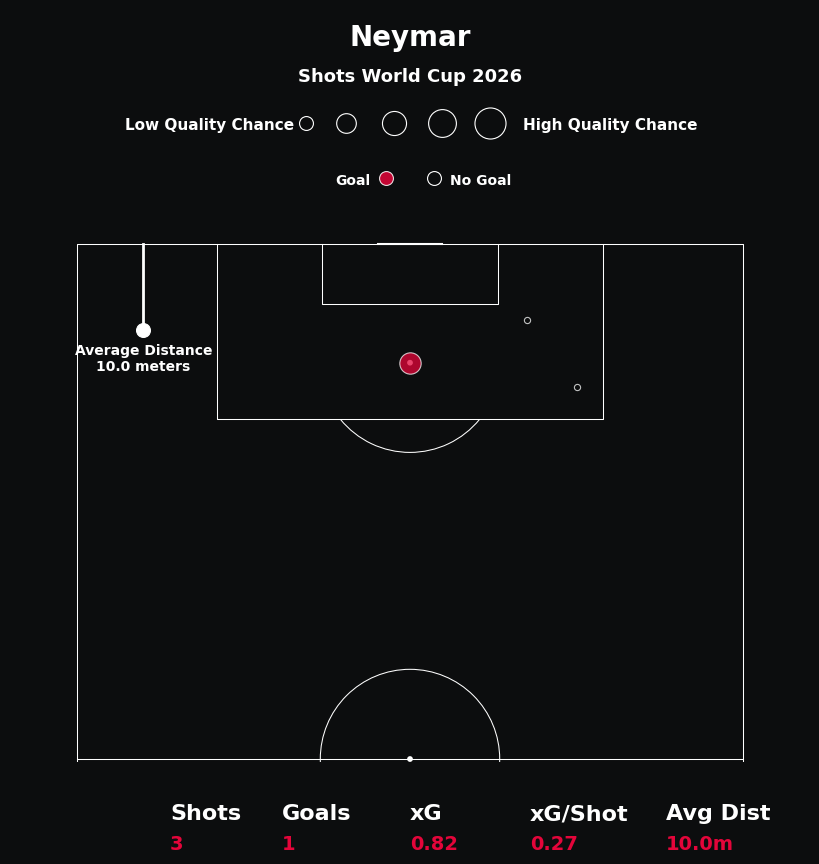

{'total_shots': 3,
 'total_goals': 1,
 'total_xg': np.float64(0.815788715185225),
 'xg_per_shot': np.float64(0.2719295717284083),
 'avg_distance_meters': np.float64(9.99744)}

In [38]:
stats = build_shot_map("Neymar", save=True)
stats